# Proyek Klasifikasi Gambar: Fruits 360
- **Nama:** Frans Christiopan Hutapea
- **Email:** franshutapea05@gmail.com
- **ID Dicoding:** frans_pemula

## Import Semua Packages/Library yang Digunakan

In [7]:
import os
import random
import shutil
import zipfile
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

## Data Preparation

### Data Loading

Training Data

In [8]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("moltean/fruits")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'fruits' dataset.
Path to dataset files: /kaggle/input/fruits


In [9]:
import os

training_dir = os.path.join(path, "fruits-360_100x100/fruits-360/Training")
fruits = ["Cherry", "Peach", "Plum"]

# Data hanya dibatasi pada kelas Cherry, Peach, dan Plum
selected_classes = [
    f"{fruit} {i}" for fruit in fruits
    for i in range(1, 6)
]

print(selected_classes)

['Cherry 1', 'Cherry 2', 'Cherry 3', 'Cherry 4', 'Cherry 5', 'Peach 1', 'Peach 2', 'Peach 3', 'Peach 4', 'Peach 5', 'Plum 1', 'Plum 2', 'Plum 3', 'Plum 4', 'Plum 5']


In [10]:
filtered_dir = "/content/fruits_filtered/"

for cls in selected_classes:
  source_dir = os.path.join(training_dir, cls)
  base_class = cls.split()[0]

  target_dir = os.path.join(filtered_dir, base_class)
  os.makedirs(target_dir, exist_ok=True)

  for img in os.listdir(source_dir):
    new_name = f"{cls}_{img}" # Renew nama file agar tidak ada overwrite

    shutil.copy(
        os.path.join(source_dir, img),
        os.path.join(target_dir, new_name)
    )

In [11]:
for cls in ["Cherry", "Peach", "Plum"]:
    print(
        cls,
        len(os.listdir(os.path.join(filtered_dir, cls)))
    )

Cherry 3321
Peach 3597
Plum 3143


Test

In [12]:
test_dir = os.path.join(path, "fruits-360_100x100/fruits-360/Test")

filtered_test = "/content/test_filtered/"

for cls in selected_classes:
  source_dir = os.path.join(test_dir, cls)
  base_class = cls.split()[0]

  target_dir = os.path.join(filtered_test, base_class)
  os.makedirs(target_dir, exist_ok=True)

  for img in os.listdir(source_dir):
    new_name = f"{cls}_{img}" # Renew nama file agar tidak ada overwrite

    shutil.copy(
        os.path.join(source_dir, img),
        os.path.join(target_dir, new_name)
    )

### Data Preprocessing

In [13]:
# Resize
IMG_SIZE = (150, 150)

# Rescaling
normalizatoin_layer = tf.keras.layers.Rescaling(1./255)

# Augmentasi Data
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

#### Split Dataset

In [14]:
# Train
dataset_path = "/content/fruits_filtered"
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.30,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 10061 files belonging to 3 classes.
Using 7043 files for training.


In [15]:
# Validation
val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.30,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 10061 files belonging to 3 classes.
Using 3018 files for validation.


In [16]:
# Test
test_ds = tf.keras.utils.image_dataset_from_directory(
    filtered_test,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 3349 files belonging to 3 classes.


## Modelling

In [17]:
model = tf.keras.Sequential([

    # Data Augmentation
    data_augmentation,

    # Normalization
    tf.keras.layers.Rescaling(1./255),

    # Block 1
    tf.keras.layers.Conv2D(
        32,
        (3, 3),
        activation='relu',
        input_shape=(150, 150, 3)
    ),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.BatchNormalization(),

    # Block 2
    tf.keras.layers.Conv2D(
        64,
        (3, 3),
        activation='relu'
    ),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.BatchNormalization(),

    # Block 3
    tf.keras.layers.Conv2D(
        128,
        (3, 3),
        activation='relu'
    ),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.BatchNormalization(),

    # Block 4
    tf.keras.layers.Conv2D(
        256,
        (3, 3),
        activation='relu'
    ),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.BatchNormalization(),

    # Fully Connected
    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(
        512,
        activation='relu'
    ),

    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(
        3,
        activation='softmax'
    )
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [18]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [19]:
callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ModelCheckpoint(
        filepath='best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        verbose=1
    )
]

In [20]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks
)

Epoch 1/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8909 - loss: 1.3823
Epoch 1: val_accuracy improved from None to 0.40789, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
221/221 ━━━━━━━━━━━━━━━━━━━━ 545s 2s/step - accuracy: 0.9502 - loss: 0.5865 - val_accuracy: 0.4079 - val_loss: 27.6462 - learning_rate: 0.0010
Epoch 2/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9853 - loss: 0.1257
Epoch 2: val_accuracy improved from 0.40789 to 0.99437, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
221/221 ━━━━━━━━━━━━━━━━━━━━ 521s 2s/step - accuracy: 0.9780 - loss: 0.2153 - val_accuracy: 0.9944 - val_loss: 0.0134 - learning_rate: 0.0010
Epoch 3/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9537 - loss: 0.4491
Epoch 3: val_accuracy improved from 0.99437 to 0.99834, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
221/221 ━━━━━━━━━━━━━━━━━━━━ 501s 2s/ste

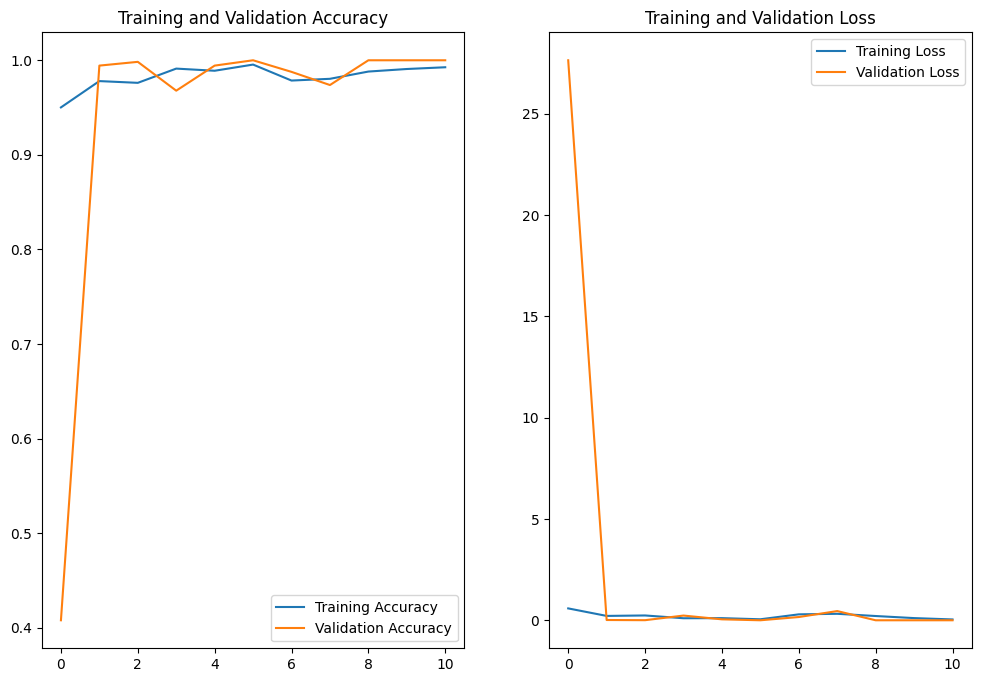

In [33]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

## Evaluasi dan Visualisasi

In [21]:
train_loss, train_acc = model.evaluate(
    train_ds,
    verbose=0
)

test_loss, test_acc = model.evaluate(
    test_ds,
    verbose=0
)

print(f"Train Accuracy : {train_acc:.4f}")
print(f"Test Accuracy  : {test_acc:.4f}")

Train Accuracy : 1.0000
Test Accuracy  : 1.0000


Visualitation

105/105 ━━━━━━━━━━━━━━━━━━━━ 53s 501ms/step


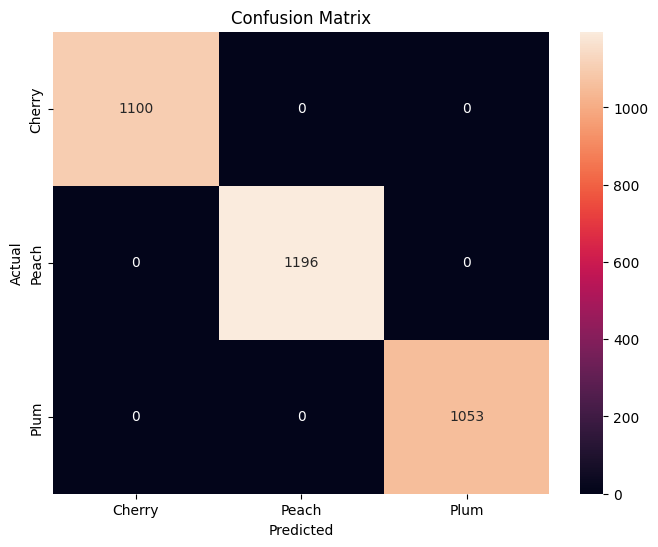

In [22]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_true = np.concatenate([
    y.numpy() for _, y in test_ds
])

y_pred = np.argmax(
    model.predict(test_ds),
    axis=1
)

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=train_ds.class_names,
    yticklabels=train_ds.class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Konversi Model

In [23]:
saved_model_path = "saved_model"
model.export(saved_model_path)
print(f"SavedModel berhasil disimpan di: {saved_model_path}")

Saved artifact at 'saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  138849805148112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138849805150416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138849805151568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138849804264912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138849804270096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138849784759312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138849784759120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138849804271440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138849804270672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138849784759504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138849784760464: Te

In [24]:
labels = train_ds.class_names

with open("label.txt", "w") as f:
    for label in labels:
        f.write(label + "\n")

TFLITE

In [25]:
model_for_tflite = tf.keras.Sequential(model.layers[2:])

converter = tf.lite.TFLiteConverter.from_keras_model(model_for_tflite)

tflite_model = converter.convert()

with open("model.tflite", "wb") as f:
    f.write(tflite_model)

print("TFLite berhasil dibuat")

Saved artifact at '/tmp/tmpfbmu6wzx'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='keras_tensor_23')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  138849804264912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138849804270096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138849784759312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138849784759120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138849804271440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138849804270672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138849784759504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138849784760464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138849784760848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138849784761040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13884980426

In [26]:
interpreter = tf.lite.Interpreter(
    model_path="model.tflite"
)

interpreter.allocate_tensors()

print("TFLite berhasil dimuat")

TFLite berhasil dimuat


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [1]:
!pip install tensorflowjs

In [27]:
import tensorflow as tf

# Create a new model without the data augmentation and rescaling layers
# Assuming 'model' is the original model with augmentation layers
# model.layers[0] is data_augmentation
# model.layers[1] is Rescaling
# So, we start from model.layers[2:]
model_for_tfjs = tf.keras.Sequential(model.layers[2:])

# Define a new path for this cleaned saved model
tfjs_saved_model_path = "tfjs_saved_model"

# Export this model
model_for_tfjs.export(tfjs_saved_model_path)

print(f"TFJS-ready SavedModel exported to: {tfjs_saved_model_path}")

# Now, use the tensorflowjs_converter on this new saved model
!tensorflowjs_converter \
    --input_format=tf_saved_model \
    {tfjs_saved_model_path} \
    tfjs_model

Saved artifact at 'tfjs_saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='keras_tensor_40')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  138849804264912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138849804270096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138849784759312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138849784759120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138849804271440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138849804270672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138849784759504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138849784760464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138849784760848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138849784761040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13884980426

In [28]:
import os

print(os.listdir("tfjs_model"))

['group1-shard2of7.bin', 'group1-shard1of7.bin', 'model.json', 'group1-shard6of7.bin', 'group1-shard7of7.bin', 'group1-shard4of7.bin', 'group1-shard3of7.bin', 'group1-shard5of7.bin']


## Inference (Optional)

Testing with 9 Random sample

In [30]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

sample_images = []

for class_name in os.listdir(filtered_test):
    class_dir = os.path.join(filtered_test, class_name)

    if os.path.isdir(class_dir):
        img_file = random.choice(os.listdir(class_dir))
        sample_images.append(
            os.path.join(class_dir, img_file)
        )

sample_images = sample_images[:9]

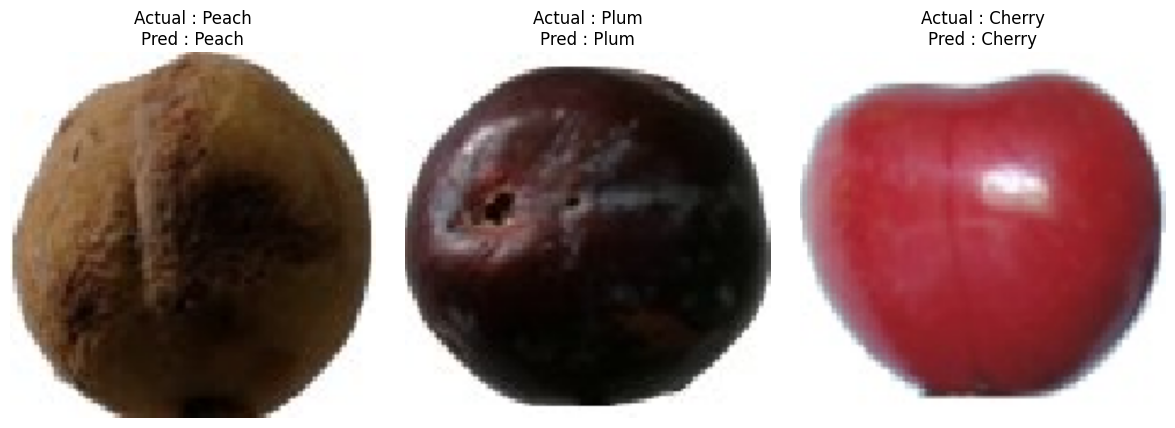

In [31]:
from tensorflow.keras.utils import load_img, img_to_array

plt.figure(figsize=(12, 12))

for i, img_path in enumerate(sample_images):

    img = load_img(
        img_path,
        target_size=IMG_SIZE
    )

    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(
        img_array,
        verbose=0
    )

    predicted_class = train_ds.class_names[
        np.argmax(prediction)
    ]

    actual_class = os.path.basename(
        os.path.dirname(img_path)
    )

    plt.subplot(3, 3, i + 1)

    plt.imshow(img)

    plt.title(
        f"Actual : {actual_class}\nPred : {predicted_class}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [32]:
test_loss, test_acc = model.evaluate(
    test_ds,
    verbose=1
)

print(f"Test Accuracy: {test_acc:.4f}")

105/105 ━━━━━━━━━━━━━━━━━━━━ 56s 526ms/step - accuracy: 1.0000 - loss: 4.9759e-06
Test Accuracy: 1.0000
